Credit Card Fraud Detection Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,roc_auc_score,accuracy_score
from imblearn.over_sampling import SMOTE
import pickle

In [2]:
train_df= pd.read_excel("fraudTrain.xlsx")
train_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,2019-01-11 16:37:15,343472729187663,"fraud_Schroeder, Wolff and Hermiston",travel,11872.21,F,234 Bridges Wells Apt. 389,Center Tuftonboro,43.6849,-71.2551,1368,"Optician, dispensing",1971-08-05,43.235621,-71.391741,0
1,2019-01-22 15:24:15,2264937662466770,"fraud_Ritchie, Bradtke and Stiedemann",travel,10776.59,M,5939 Garcia Forges Suite 297,San Antonio,29.3641,-98.4924,1595797,Land,1995-10-17,29.772325,-98.593405,0
2,2019-01-15 19:36:47,4969856774088580,"fraud_Champlin, Rolfson and Connelly",travel,6337.25,F,27823 Andrew Underpass Suite 948,Metairie,29.9975,-90.2146,137067,Advertising account planner,1951-12-04,30.442968,-89.442589,0
3,2019-01-07 23:50:36,3567697931646320,fraud_Pouros-Haag,shopping_pos,5444.24,M,428 Morgan River,Hudson,42.2470,-73.7552,17867,Travel agency manager,1998-07-29,41.588036,-73.799288,0
4,2019-01-26 12:52:07,371034293500716,"fraud_Schroeder, Wolff and Hermiston",travel,5234.79,M,5758 Yates Center,Vinton,40.0235,-120.7986,128,Education administrator,1966-02-21,40.817192,-120.227632,0


In [3]:
train_df['is_fraud'].value_counts()

is_fraud
0    44064
1     6006
Name: count, dtype: int64

In [4]:
train_df.shape

(50070, 16)

In [5]:
train_df.describe()

,trans_date_trans_time,cc_num,amt,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud
count,50070,5.007000e+04,50070.000000,50070.000000,50070.000000,5.007000e+04,50070,50070.000000,50070.000000,50070.000000
mean,2019-02-06 18:35:08.381465856,4.144496e+17,123.017600,38.548057,-90.188600,8.902307e+04,1973-05-11 07:33:56.620730976,38.547706,-90.191230,0.119952
min,2019-01-01 00:00:18,6.041621e+10,1.000000,20.027100,-165.672300,2.300000e+01,1924-10-30 00:00:00,19.040141,-166.629875,0.000000
25%,2019-01-08 05:26:35,1.800385e+14,11.872500,34.703200,-96.790900,7.430000e+02,1962-03-04 00:00:00,34.821815,-96.871557,0.000000
50%,2019-01-15 12:03:41,3.520550e+15,52.860000,39.371600,-87.420800,2.457000e+03,1975-06-29 00:00:00,39.372439,-87.352614,0.000000
75%,2019-01-22 17:24:02,4.642255e+15,99.630000,41.894800,-80.128400,2.112500e+04,1987-01-27 00:00:00,41.936520,-80.161675,0.000000
max,2020-03-10 12:09:33,4.992346e+18,11872.210000,66.693300,-67.950300,2.906700e+06,2005-01-29 00:00:00,67.510267,-66.967742,1.000000
std,NaN,1.304700e+18,241.068026,5.088945,13.917777,2.980411e+05,NaN,5.121294,13.933088,0.324909


In [6]:
train_df.describe(include=object)

,merchant,category,gender,street,city,job
count,50070,50070,50070,50070,50070,50070
unique,693,14,2,965,879,493
top,fraud_Cormier LLC,grocery_pos,F,72269 Elizabeth Field Apt. 132,Utica,Exhibition designer
freq,182,5562,27001,136,213,364


In [7]:
train_df.isnull().sum()/train_df.shape[0]*100

trans_date_trans_time    0.0
cc_num                   0.0
merchant                 0.0
category                 0.0
amt                      0.0
gender                   0.0
street                   0.0
city                     0.0
lat                      0.0
long                     0.0
city_pop                 0.0
job                      0.0
dob                      0.0
merch_lat                0.0
merch_long               0.0
is_fraud                 0.0
dtype: float64

In [8]:
train_df['trans_date_trans_time']=pd.to_datetime(train_df['trans_date_trans_time'])

In [9]:
train_df['hour']=train_df['trans_date_trans_time'].dt.hour

In [10]:
train_df["dob"] = pd.to_datetime(train_df["dob"])
train_df["age"] = (pd.Timestamp.now() - train_df["dob"]).dt.days // 365

In [11]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = np.radians(lat2-lat1)
    dlon = np.radians(lon2-lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


train_df["distance"] = haversine(
    train_df["lat"], train_df["long"],
    train_df["merch_lat"], train_df["merch_long"]
)


In [12]:
drop_cols=["trans_date_trans_time",
    "dob",
    "cc_num",
    "street",
    "merchant",
    "city",
    "job"
]

In [13]:
train_df.drop(columns=drop_cols,inplace=True)

In [14]:
train_df

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour,age,distance
0,travel,11872.21,F,43.6849,-71.2551,1368,43.235621,-71.391741,0,16,54,51.160340
1,travel,10776.59,M,29.3641,-98.4924,1595797,29.772325,-98.593405,0,15,30,46.431756
2,travel,6337.25,F,29.9975,-90.2146,137067,30.442968,-89.442589,0,19,74,89.195236
3,shopping_pos,5444.24,M,42.2470,-73.7552,17867,41.588036,-73.799288,0,23,27,73.364198
4,travel,5234.79,M,40.0235,-120.7986,128,40.817192,-120.227632,0,12,60,100.622849
...,...,...,...,...,...,...,...,...,...,...,...,...
50065,shopping_pos,1.00,F,34.9906,-81.8327,167,35.134181,-82.804672,0,13,37,89.893768
50066,health_fitness,1.00,F,39.9458,-75.9703,3066,39.102257,-76.958004,0,13,97,126.389935
50067,shopping_pos,1.00,F,41.0442,-73.9609,5950,41.729484,-74.904069,0,13,54,109.532483
50068,shopping_pos,1.00,M,35.1959,-83.8228,5354,35.600491,-84.324442,0,0,60,63.963704


In [15]:
from sklearn.preprocessing import LabelEncoder

cat_cols= ['gender','category']

le_dict={}
for i in cat_cols:
    le=LabelEncoder()
    train_df[i]= le.fit_transform(train_df[i])
    le_dict[i]=le

In [16]:
smote = SMOTE(random_state=42)

In [17]:
x=train_df.drop(columns="is_fraud")
y=train_df['is_fraud']

In [18]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.25,random_state=42)

In [19]:
X_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_sm.value_counts())

Before SMOTE: is_fraud
0    33083
1     4469
Name: count, dtype: int64
After SMOTE: is_fraud
0    33083
1    33083
Name: count, dtype: int64


In [20]:
model= RandomForestClassifier()

In [21]:
model.fit(X_train_sm,y_train_sm)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

print("test_accuracy",accuracy_score(y_pred,y_test))




print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

test_accuracy 0.9789902540341907

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     10981
           1       0.89      0.94      0.92      1537

    accuracy                           0.98     12518
   macro avg       0.94      0.96      0.95     12518
weighted avg       0.98      0.98      0.98     12518

ROC-AUC Score: 0.9946471390786369


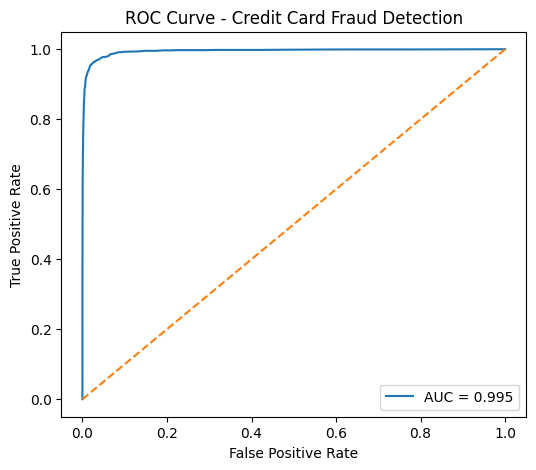

In [23]:
from sklearn.metrics import roc_curve, auc

# predicted probabilities for class 1 (fraud)
y_prob = model.predict_proba(x_test)[:, 1]

# compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# compute AUC score
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")  # diagonal line (random model)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Fraud Detection")
plt.legend()
plt.show()

In [25]:
# Test model on test dataset

In [26]:
test_df= pd.read_excel("fraudTrain.xlsx")
test_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,2019-01-11 16:37:15,343472729187663,"fraud_Schroeder, Wolff and Hermiston",travel,11872.21,F,234 Bridges Wells Apt. 389,Center Tuftonboro,43.6849,-71.2551,1368,"Optician, dispensing",1971-08-05,43.235621,-71.391741,0
1,2019-01-22 15:24:15,2264937662466770,"fraud_Ritchie, Bradtke and Stiedemann",travel,10776.59,M,5939 Garcia Forges Suite 297,San Antonio,29.3641,-98.4924,1595797,Land,1995-10-17,29.772325,-98.593405,0
2,2019-01-15 19:36:47,4969856774088580,"fraud_Champlin, Rolfson and Connelly",travel,6337.25,F,27823 Andrew Underpass Suite 948,Metairie,29.9975,-90.2146,137067,Advertising account planner,1951-12-04,30.442968,-89.442589,0
3,2019-01-07 23:50:36,3567697931646320,fraud_Pouros-Haag,shopping_pos,5444.24,M,428 Morgan River,Hudson,42.2470,-73.7552,17867,Travel agency manager,1998-07-29,41.588036,-73.799288,0
4,2019-01-26 12:52:07,371034293500716,"fraud_Schroeder, Wolff and Hermiston",travel,5234.79,M,5758 Yates Center,Vinton,40.0235,-120.7986,128,Education administrator,1966-02-21,40.817192,-120.227632,0


In [28]:
test_df.shape

(50070, 16)

In [29]:
test_df['is_fraud'].value_counts()

is_fraud
0    44064
1     6006
Name: count, dtype: int64

In [30]:
test_df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'gender', 'street', 'city', 'lat', 'long', 'city_pop', 'job', 'dob',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [35]:
test_df['trans_date_trans_time']=pd.to_datetime(test_df['trans_date_trans_time'])

In [36]:
test_df['dob']=pd.to_datetime(test_df['dob'])

In [39]:
test_df['hour']=test_df['trans_date_trans_time'].dt.hour

In [40]:
drop_cols=["trans_date_trans_time",
    "dob",
    "cc_num",
    "street",
    "merchant",
    "city",
    "job"
]

In [41]:
test_df.drop(columns=drop_cols, inplace=True)

In [42]:
test_df

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour
0,travel,11872.21,F,43.6849,-71.2551,1368,43.235621,-71.391741,0,16
1,travel,10776.59,M,29.3641,-98.4924,1595797,29.772325,-98.593405,0,15
2,travel,6337.25,F,29.9975,-90.2146,137067,30.442968,-89.442589,0,19
3,shopping_pos,5444.24,M,42.2470,-73.7552,17867,41.588036,-73.799288,0,23
4,travel,5234.79,M,40.0235,-120.7986,128,40.817192,-120.227632,0,12
...,...,...,...,...,...,...,...,...,...,...
50065,shopping_pos,1.00,F,34.9906,-81.8327,167,35.134181,-82.804672,0,13
50066,health_fitness,1.00,F,39.9458,-75.9703,3066,39.102257,-76.958004,0,13
50067,shopping_pos,1.00,F,41.0442,-73.9609,5950,41.729484,-74.904069,0,13
50068,shopping_pos,1.00,M,35.1959,-83.8228,5354,35.600491,-84.324442,0,0


In [44]:
from sklearn.preprocessing import LabelEncoder

cat_cols= ['gender','category']

le_dict={}

for i in cat_cols:
    le=LabelEncoder()
    test_df[i]= le.fit_transform(test_df[i])
    le_dict[i]=le

In [ ]:
test_df

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,is_fraud,hour
0,13,11872.21,0,43.6849,-71.2551,1368,43.235621,-71.391741,0,16
1,13,10776.59,1,29.3641,-98.4924,1595797,29.772325,-98.593405,0,15
2,13,6337.25,0,29.9975,-90.2146,137067,30.442968,-89.442589,0,19
3,12,5444.24,1,42.2470,-73.7552,17867,41.588036,-73.799288,0,23
4,13,5234.79,1,40.0235,-120.7986,128,40.817192,-120.227632,0,12
...,...,...,...,...,...,...,...,...,...,...
50065,12,1.00,0,34.9906,-81.8327,167,35.134181,-82.804672,0,13
50066,5,1.00,0,39.9458,-75.9703,3066,39.102257,-76.958004,0,13
50067,12,1.00,0,41.0442,-73.9609,5950,41.729484,-74.904069,0,13
50068,12,1.00,1,35.1959,-83.8228,5354,35.600491,-84.324442,0,0


In [52]:
X=test_df.drop(columns="is_fraud")
Y=test_df['is_fraud']

In [53]:
X

,category,amt,gender,lat,long,city_pop,merch_lat,merch_long,hour
0,13,11872.21,0,43.6849,-71.2551,1368,43.235621,-71.391741,16
1,13,10776.59,1,29.3641,-98.4924,1595797,29.772325,-98.593405,15
2,13,6337.25,0,29.9975,-90.2146,137067,30.442968,-89.442589,19
3,12,5444.24,1,42.2470,-73.7552,17867,41.588036,-73.799288,23
4,13,5234.79,1,40.0235,-120.7986,128,40.817192,-120.227632,12
...,...,...,...,...,...,...,...,...,...
50065,12,1.00,0,34.9906,-81.8327,167,35.134181,-82.804672,13
50066,5,1.00,0,39.9458,-75.9703,3066,39.102257,-76.958004,13
50067,12,1.00,0,41.0442,-73.9609,5950,41.729484,-74.904069,13
50068,12,1.00,1,35.1959,-83.8228,5354,35.600491,-84.324442,0


In [54]:
Y

0        0
1        0
2        0
3        0
4        0
        ..
50065    0
50066    0
50067    0
50068    0
50069    0
Name: is_fraud, Length: 50070, dtype: int64

In [55]:
x_train,x_test,y_train,y_test= train_test_split(X,Y,test_size=0.25,random_state=42)

In [56]:
model.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
y_pred=model.predict(x_test)

In [58]:
accuracy_score(y_pred,y_test)

0.9848218565266017

In [ ]:
y_prob = model.predict_proba(x_test)[:, 1]

print("test_accuracy",accuracy_score(y_pred,y_test))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

test_accuracy 0.9848218565266017

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     10981
           1       0.96      0.92      0.94      1537

    accuracy                           0.98     12518
   macro avg       0.97      0.96      0.96     12518
weighted avg       0.98      0.98      0.98     12518

ROC-AUC Score: 0.9960996094454745


In [ ]:
import pickle

with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [62]:
train_df.columns

Index(['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'age', 'distance'],
      dtype='object')